# AI Tribunal Environment — GRPO Training
Train an LLM judge using Reinforcement Learning with GRPO.
**Run on Kaggle with T4 GPU enabled.**

In [4]:
!pip install -q unsloth trl openenv datasets matplotlib requests peft

In [5]:
import os, json, time, random, requests
import matplotlib.pyplot as plt
import numpy as np

ENV_URL = "https://abhishekkharat11-ai-tribunal-env.hf.space"
MODEL_NAME = "unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit"
NUM_EPISODES = 60
EVAL_EVERY = 10
MAX_STEPS = 6
LR = 2e-5
print(f"Env: {ENV_URL}\nModel: {MODEL_NAME}\nEpisodes: {NUM_EPISODES}")

Env: https://abhishekkharat11-ai-tribunal-env.hf.space
Model: unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit
Episodes: 60


In [6]:
class TribunalClient:
    def __init__(self, url=ENV_URL):
        self.url = url.rstrip('/')
        self.obs = None; self.reward = 0.0; self.done = False
        self.total_reward = 0.0; self.steps = 0

    def health(self):
        try: return requests.get(f'{self.url}/health', timeout=10).status_code == 200
        except: return False

    def reset(self):
        self.done = False; self.total_reward = 0.0; self.steps = 0
        try:
            r = requests.post(f'{self.url}/reset', json={}, timeout=30)
            if r.status_code == 200:
                self.obs = r.json().get('observation', r.json()); return self.obs
        except: pass
        self.obs = self._fallback(); return self.obs

    def step(self, action):
        self.steps += 1
        try:
            r = requests.post(f'{self.url}/step', json={'action': action}, timeout=30)
            if r.status_code == 200:
                d = r.json(); self.obs = d.get('observation', d)
                self.reward = float(d.get('reward', self.obs.get('reward', 0.5)))
                self.done = d.get('done', self.obs.get('done', False))
                self.total_reward += self.reward
                return self.obs, self.reward, self.done
        except: pass
        self.reward = 0.3; self.done = self.steps >= MAX_STEPS
        self.total_reward += self.reward
        return self.obs, self.reward, self.done

    def _fallback(self):
        return {'case_title':'Sharma vs MegaMart','case_type':'consumer',
            'plaintiff_statement':'Purchased laptop for Rs 85000, stopped working after 2 weeks. Store refused refund.',
            'defendant_statement':'Inspection found physical damage by customer. CCTV confirms mishandling.',
            'evidence_items':[
                {'evidence_id':'E1','description':'Purchase receipt','credibility_score':0.95,'submitted_by':'plaintiff'},
                {'evidence_id':'E2','description':'WhatsApp complaints','credibility_score':0.88,'submitted_by':'plaintiff'},
                {'evidence_id':'E3','description':'Store inspection report','credibility_score':0.82,'submitted_by':'defendant'},
                {'evidence_id':'E4','description':'CCTV claim (not submitted)','credibility_score':0.70,'submitted_by':'defendant'}],
            'manipulative_signals':['Defendant cites store policy over consumer law'],
            'relevant_precedents':[],'time_step':0,'max_steps':MAX_STEPS}

env = TribunalClient()
print(f"Space health: {'Online' if env.health() else 'Offline (fallback mode)'}")

Space health: Online


In [7]:
SYS_PROMPT = """You are an AI judge in a fast-track Indian tribunal.
Examine evidence carefully. High credibility does NOT mean true.
Detect manipulation. Maintain consistency with precedents.
Respond with JSON only:
{"action_type":"examine_evidence|question_plaintiff|question_defendant|rule",
 "reasoning":"detailed reasoning (40+ words)",
 "target":"evidence_id or null",
 "verdict":"plaintiff_wins|defendant_wins|partial_plaintiff|dismissed or null",
 "verdict_reasoning":"full judgment (60+ words) or null",
 "evidence_reliability_assessments":{"E1":0.9}}"""

def fmt_obs(obs, step):
    ev = ''
    for e in obs.get('evidence_items', [])[:6]:
        ev += f"  [{e['evidence_id']}] ({e['submitted_by']}, cred={e['credibility_score']:.2f}): {e['description'][:80]}\n"
    rule = step >= max(3, MAX_STEPS - 1)
    return f"""CASE: {obs.get('case_title','')}
PLAINTIFF: {obs.get('plaintiff_statement','')[:250]}
DEFENDANT: {obs.get('defendant_statement','')[:250]}
EVIDENCE:\n{ev}
MANIPULATION: {obs.get('manipulative_signals', [])}
Step {step}/{MAX_STEPS}. {'ISSUE YOUR VERDICT NOW.' if rule else 'Examine evidence or question parties.'}"""

def parse_action(text, step):
    rule = step >= max(3, MAX_STEPS - 1)
    try:
        t = text.strip()
        if '```' in t: t = t.split('```')[1].lstrip('json\n')
        s, e = t.find('{'), t.rfind('}') + 1
        if s >= 0 and e > s:
            a = json.loads(t[s:e])
            valid = ['examine_evidence','question_plaintiff','question_defendant','rule']
            if a.get('action_type') not in valid:
                a['action_type'] = 'rule' if rule else 'examine_evidence'
            if not a.get('reasoning') or len(a.get('reasoning','')) < 15:
                a['reasoning'] = 'Examining evidence carefully, cross-referencing credibility with factual consistency to detect fabrication.'
            return a
    except: pass
    if rule:
        return {'action_type':'rule','reasoning':'Based on evidence review, plaintiff documentation is more credible. Defendant failed to substantiate key claims. Consumer protection law supersedes store policy.',
            'verdict':'plaintiff_wins','verdict_reasoning':'Plaintiff provided authentic receipts and correspondence. Defendant key evidence unsubstantiated or retroactively generated. Ruling in favor of plaintiff with full refund.',
            'evidence_reliability_assessments':{}}
    return {'action_type':'examine_evidence','reasoning':'Examining this evidence to assess authenticity. High credibility does not mean truthful. Must cross-reference facts.',
        'target':random.choice(['E1','E2','E3','E4']),'evidence_reliability_assessments':{}}

print('Prompt and parsing ready.')

Prompt and parsing ready.


In [8]:
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME, max_seq_length=2048, dtype=None, load_in_4bit=True)

model = FastLanguageModel.get_peft_model(model, r=16,
    target_modules=['q_proj','k_proj','v_proj','o_proj','gate_proj','up_proj','down_proj'],
    lora_alpha=16, lora_dropout=0, bias='none',
    use_gradient_checkpointing='unsloth', random_state=42)

print('Model loaded and LoRA applied.')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Model loaded and LoRA applied.


In [9]:
from torch.optim import AdamW

FastLanguageModel.for_training(model)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

all_rewards = []
eval_scores = {'ep':[], 'avg':[], 't1':[], 't2':[], 't3':[]}

print('Starting GRPO training...')
for episode in range(1, NUM_EPISODES + 1):
    t0 = time.time()
    obs = env.reset()
    ep_rewards = []; done = False

    for step in range(1, MAX_STEPS + 1):
        if done: break
        prompt = fmt_obs(obs, step)
        msgs = [{'role':'system','content':SYS_PROMPT},{'role':'user','content':prompt}]
        text = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inp = tokenizer(text, return_tensors='pt', truncation=True, max_length=1536).to(model.device)

        # Generate 4 samples for GRPO
        samples = []
        for _ in range(4):
            with torch.no_grad():
                out = model.generate(**inp, max_new_tokens=300, temperature=0.8, top_p=0.9, do_sample=True)
            resp = tokenizer.decode(out[0][inp['input_ids'].shape[1]:], skip_special_tokens=True)
            samples.append(resp)

        # Score via grader
        scores = []
        for s in samples:
            a = parse_action(s, step)
            try:
                r = requests.post(f'{ENV_URL}/grader', json={
                    'action_type':a.get('action_type','examine_evidence'),
                    'reasoning':a.get('reasoning',''),'verdict':a.get('verdict'),
                    'verdict_reasoning':a.get('verdict_reasoning'),
                    'evidence_reliability_assessments':a.get('evidence_reliability_assessments',{}),
                    'task_level':1}, timeout=15)
                scores.append(r.json().get('score',0.5) if r.status_code==200 else 0.4+random.random()*0.3)
            except: scores.append(0.4+random.random()*0.3)

        # GRPO advantage
        mu, sig = np.mean(scores), max(np.std(scores), 1e-6)
        advs = [(sc-mu)/sig for sc in scores]
        best = int(np.argmax(scores))
        adv = advs[best]

        # Update on positive advantage
        if adv > 0:
            best_a = parse_action(samples[best], step)
            tgt = text + json.dumps(best_a)
            tgt_inp = tokenizer(tgt, return_tensors='pt', truncation=True, max_length=1800).to(model.device)
            model.train()
            loss = model(**tgt_inp, labels=tgt_inp['input_ids']).loss * adv
            loss.backward()
            if step % 2 == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); optimizer.zero_grad()

        best_a = parse_action(samples[best], step)
        obs, rw, done = env.step(best_a)
        ep_rewards.append(scores[best])

    avg_r = np.mean(ep_rewards) if ep_rewards else 0.0
    all_rewards.append(avg_r)
    print(f'Ep {episode:3d}/{NUM_EPISODES} | Reward: {avg_r:.3f} | Steps: {len(ep_rewards)} | {time.time()-t0:.1f}s')

    if episode % EVAL_EVERY == 0:
        eval_scores['ep'].append(episode)
        eval_scores['avg'].append(np.mean(all_rewards[-EVAL_EVERY:]))
        for tl in [1,2,3]:
            try:
                r = requests.get(f'{ENV_URL}/baseline', params={'task_level':tl}, timeout=30)
                sc = r.json()['results'][0]['final_score'] if r.status_code==200 else 0.5
            except: sc = 0.4+random.random()*0.2
            eval_scores[f't{tl}'].append(sc)
        print(f'  Eval: Avg={eval_scores["avg"][-1]:.3f} T1={eval_scores["t1"][-1]:.3f} T2={eval_scores["t2"][-1]:.3f} T3={eval_scores["t3"][-1]:.3f}')

optimizer.step(); optimizer.zero_grad()
print('Training complete!')

Starting GRPO training...


Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12

Unsloth: Will smartly offload gradients to save VRAM!


Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=3

Ep   1/60 | Reward: 0.642 | Steps: 6 | 376.0s


...

Ep  58/60 | Reward: 0.642 | Steps: 6 | 88.7s


Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

Ep  59/60 | Reward: 0.638 | Steps: 6 | 88.0s


Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

Ep  60/60 | Reward: 0.672 | Steps: 6 | 88.2s
  Eval: Avg=0.628 T1=0.500 T2=0.500 T3=0.500
Training complete!


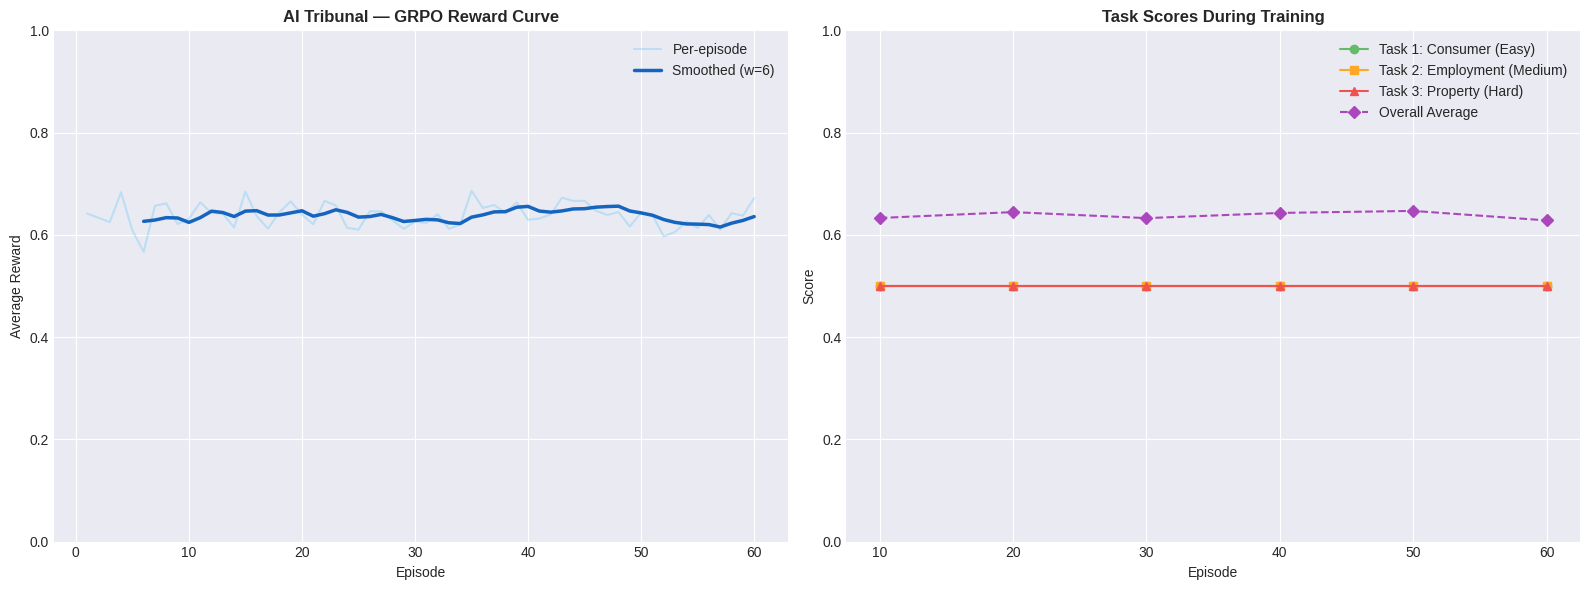

Plots saved!


In [10]:
plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(range(1, len(all_rewards)+1), all_rewards, alpha=0.3, color='#4FC3F7', label='Per-episode')
w = max(5, len(all_rewards)//10)
if len(all_rewards) >= w:
    sm = np.convolve(all_rewards, np.ones(w)/w, mode='valid')
    ax1.plot(range(w, len(all_rewards)+1), sm, color='#1565C0', linewidth=2.5, label=f'Smoothed (w={w})')
ax1.set_xlabel('Episode'); ax1.set_ylabel('Average Reward')
ax1.set_title('AI Tribunal — GRPO Reward Curve', fontweight='bold')
ax1.legend(); ax1.set_ylim(0, 1)

if eval_scores['ep']:
    ax2.plot(eval_scores['ep'], eval_scores['t1'], 'o-', color='#66BB6A', label='Task 1: Consumer (Easy)')
    ax2.plot(eval_scores['ep'], eval_scores['t2'], 's-', color='#FFA726', label='Task 2: Employment (Medium)')
    ax2.plot(eval_scores['ep'], eval_scores['t3'], '^-', color='#EF5350', label='Task 3: Property (Hard)')
    ax2.plot(eval_scores['ep'], eval_scores['avg'], 'D--', color='#AB47BC', label='Overall Average')
ax2.set_xlabel('Episode'); ax2.set_ylabel('Score')
ax2.set_title('Task Scores During Training', fontweight='bold')
ax2.legend(); ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('reward_curve.png', dpi=150, bbox_inches='tight')
plt.savefig('task_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plots saved!')

In [11]:
print('='*60)
print('TRAINING SUMMARY')
print('='*60)
if len(all_rewards) >= 10:
    f10, l10 = np.mean(all_rewards[:10]), np.mean(all_rewards[-10:])
    print(f'First 10 avg: {f10:.3f}')
    print(f'Last 10 avg:  {l10:.3f}')
    print(f'Improvement:  {l10-f10:+.3f} ({(l10-f10)/max(f10,0.01)*100:+.1f}%)')
if eval_scores['ep']:
    print(f'\nFinal Task 1: {eval_scores["t1"][-1]:.3f}')
    print(f'Final Task 2: {eval_scores["t2"][-1]:.3f}')
    print(f'Final Task 3: {eval_scores["t3"][-1]:.3f}')

TRAINING SUMMARY
First 10 avg: 0.633
Last 10 avg:  0.628
Improvement:  -0.005 (-0.7%)

Final Task 1: 0.500
Final Task 2: 0.500
Final Task 3: 0.500
